# Graph2vec + TimeDistributed MLP — Dissertation Evaluation Suite

Three conditions evaluated over 10 random seeds per product:
- **Baseline** (`ablate_z = 'baseline'`): pure MLP, no graph structure
- **Ablated Graph2vec** (`ablate_z = 'True'`): graph is built but embedding *z* is zeroed out
- **Proposed Graph2vec** (`ablate_z = 'False'`): full model — graph2vec embedding fed into MLP

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
import warnings
import os
warnings.filterwarnings('ignore')

In [5]:

# ── Load & sanitise ───────────────────────────────────────────────────────────
df_raw = pd.read_csv("TimeDistributedMLP/graph2vec_mlp2_finalresults.csv")

# Drop the experiment-time sentinel row
df = df_raw[df_raw['item_id'] != 'TOTAL_EXPERIMENT_TIME_SECONDS'].copy()
df['item_id'] = df['item_id'].astype(int)

# Replace name r2_score for composite_score, which is what we actually care about. The original r2_score column was a misnomer.
df.rename(columns={'r2_score': 'composite_score'}, inplace=True)
df['composite_score'] = (0.50 * df['rmse']) + (0.25 * df['mae']) + (0.25 * df['bias'].abs())
# Three conditions — ablate_z is stored as a string in the CSV
BASELINE = df[df['ablate_z'] == 'baseline'].copy()   # pure MLP, no graph
ABLATED  = df[df['ablate_z'] == 'True'].copy()        # graph built, z ablated
PROPOSED = df[df['ablate_z'] == 'False'].copy()       # full graph2vec + MLP

METRICS       = ['rmse', 'mae', 'composite_score', 'pocid']
METRIC_LABELS = {'rmse': 'RMSE ↓', 'mae': 'MAE ↓', 'composite_score': 'R² ↓', 'pocid': 'POCID ↑'}
# For each metric: does a *lower* or *higher* value mean better performance?
BETTER        = {'rmse': 'lower', 'mae': 'lower', 'composite_score': 'lower', 'pocid': 'higher'}

PALETTE = {
    'Baseline\n(MLP)':        '#7f8c8d',
    'Ablated\nGraph2vec':     '#f39c12',
    'Proposed\nGraph2vec':    '#27ae60',
}
df.to_csv("evaluation_suite.csv", index=False)
print(f"Products : {df['item_id'].nunique()}")
print(f"Seeds    : {df['seed'].nunique()}  {sorted(df['seed'].unique())}")
print(f"Rows     — Baseline: {len(BASELINE)}, Ablated: {len(ABLATED)}, Proposed: {len(PROPOSED)}")

Products : 61
Seeds    : 10  [42, 1000, 26008, 213626, 555555, 907969, 5219788, 13451285, 23616558, 618626816]
Rows     — Baseline: 610, Ablated: 610, Proposed: 609


In [6]:


# ── 1. Aggregate: mean across all item_id × seed rows ─────────────────────────
def _agg(cond_df, metrics):
    """Return {metric: (mean, std)} computed across all rows of cond_df."""
    return {m: (cond_df[m].mean(), cond_df[m].std()) for m in metrics}

stats_base = _agg(BASELINE, METRICS)
stats_abla = _agg(ABLATED,  METRICS)
stats_prop = _agg(PROPOSED, METRICS)

# ── 2. Relative improvement: Proposed vs Baseline & Proposed vs Ablated ───────
# sign convention: positive = proposed is better
def rel_improvement(proposed_mean, reference_mean, metric):
    """Percentage improvement of proposed over reference. Positive = better."""
    if reference_mean == 0:
        return float('nan')
    if BETTER[metric] == 'lower':   # RMSE, MAE, composite_score
        return (reference_mean - proposed_mean) / abs(reference_mean) * 100
    else:                            # POCID — higher is better
        return (proposed_mean - reference_mean) / abs(reference_mean) * 100

# ── 3. Build rows ─────────────────────────────────────────────────────────────
NICE_NAMES = {
    'rmse': 'RMSE',
    'mae': 'MAE',
    'composite_score': 'Composite Score',
    'pocid': 'POCID',
}
DIRECTION = {
    'rmse': '↓',
    'mae': '↓',
    'composite_score': '↓',
    'pocid': '↑',
}

rows_app = []
for m in METRICS:
    b_mu, b_sd = stats_base[m]
    a_mu, a_sd = stats_abla[m]
    p_mu, p_sd = stats_prop[m]
    ri_vs_base = rel_improvement(p_mu, b_mu, m)
    ri_vs_abla = rel_improvement(p_mu, a_mu, m)
    rows_app.append({
        'Metric': f"{NICE_NAMES[m]} {DIRECTION[m]}",
        'Baseline mean': round(b_mu, 4),
        'Baseline std':  round(b_sd, 4),
        'Ablated mean':  round(a_mu, 4),
        'Ablated std':   round(a_sd, 4),
        'Proposed mean': round(p_mu, 4),
        'Proposed std':  round(p_sd, 4),
        'RI vs Baseline (%)': round(ri_vs_base, 2),
        'RI vs Ablated (%)':  round(ri_vs_abla, 2),
    })

appendix_df = pd.DataFrame(rows_app).set_index('Metric')

# ── 4. Display ─────────────────────────────────────────────────────────────────
def _hi(v):
    if isinstance(v, float) and v > 0:
        return 'color: #27ae60; font-weight: bold'
    if isinstance(v, float) and v < 0:
        return 'color: #c0392b'
    return ''

display(
    appendix_df.style
    .set_caption("Appendix — Summary Statistics & Relative Improvement (mean ± std across all products × 10 seeds)")
    .applymap(_hi, subset=['RI vs Baseline (%)', 'RI vs Ablated (%)'])
    .format(precision=4, subset=[c for c in appendix_df.columns if 'RI' not in c])
    .format("{:.2f}%", subset=['RI vs Baseline (%)', 'RI vs Ablated (%)'])
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('margin-bottom','6px')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
)

# ── 5. Save to CSV ─────────────────────────────────────────────────────────────
csv_path = os.path.join(os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")), "appendix_summary_table.csv")
appendix_df.to_csv(csv_path)
print(f"Saved to: {csv_path}")
print(appendix_df.to_string())

,Baseline mean,Baseline std,Ablated mean,Ablated std,Proposed mean,Proposed std,RI vs Baseline (%),RI vs Ablated (%)
Metric,,,,,,,,
RMSE ↓,16.7477,10.5040,16.6185,10.2977,16.7310,10.5928,0.10%,-0.68%
MAE ↓,12.3687,7.1905,12.2285,6.9444,12.3526,7.1343,0.13%,-1.01%
Composite Score ↓,12.4878,7.7378,12.3464,7.4785,12.4330,7.7304,0.44%,-0.70%
POCID ↑,0.5671,0.0803,0.5660,0.0843,0.5653,0.0834,-0.31%,-0.11%


Saved to: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_summary_table.csv
                   Baseline mean  Baseline std  Ablated mean  Ablated std  Proposed mean  Proposed std  RI vs Baseline (%)  RI vs Ablated (%)
Metric                                                                                                                                       
RMSE ↓                   16.7477       10.5040       16.6185      10.2977        16.7310       10.5928                0.10              -0.68
MAE ↓                    12.3687        7.1905       12.2285       6.9444        12.3526        7.1343                0.13              -1.01
Composite Score ↓        12.4878        7.7378       12.3464       7.4785        12.4330        7.7304                0.44              -0.70
POCID ↑                   0.5671        0.0803        0.5660       0.0843         0.5653        0.0834               -0.31              -0.11


## Table 1 — Overall Descriptive Statistics

In [7]:
# ── Appendix table per product (item_id) ──────────────────────────────────────
import pandas as pd
import os

# Mean and std across the 10 seeds per product per condition
def _agg_by_product(cond_df):
    agg = cond_df.groupby('item_id')[METRICS].agg(['mean', 'std']).reset_index()
    agg.columns = ['item_id'] + [f"{m}_{stat}" for m, stat in agg.columns[1:]]
    return agg

prod_base = _agg_by_product(BASELINE)
prod_abla = _agg_by_product(ABLATED)
prod_prop = _agg_by_product(PROPOSED)

# Merge all three conditions
prod_merged = prod_base.merge(prod_abla, on='item_id', suffixes=('_base', '_abla'))
prod_merged = prod_merged.merge(prod_prop, on='item_id')

# Prop columns come out without suffix after the second merge — add it explicitly
prod_merged.columns = [
    f"{c}_prop" if (c.endswith('_mean') or c.endswith('_std')) else c
    for c in prod_merged.columns
]

# RI vs min(baseline, ablated) — conservative: Proposed must beat the stronger competitor
for m in METRICS:
    prop_mean = prod_merged[f"{m}_mean_prop"]
    base_mean = prod_merged[f"{m}_mean_base"]
    abla_mean = prod_merged[f"{m}_mean_abla"]

    if BETTER[m] == 'lower':
        ref = pd.concat([base_mean, abla_mean], axis=1).min(axis=1)
        prod_merged[f"RI {NICE_NAMES[m]} (%)"] = (ref - prop_mean) / ref.abs() * 100
    else:
        ref = pd.concat([base_mean, abla_mean], axis=1).max(axis=1)
        prod_merged[f"RI {NICE_NAMES[m]} (%)"] = (prop_mean - ref) / ref.abs() * 100

# Column order
order_cols = ['item_id']
for m in METRICS:
    order_cols.extend([
        f"{m}_mean_base", f"{m}_std_base",
        f"{m}_mean_abla", f"{m}_std_abla",
        f"{m}_mean_prop", f"{m}_std_prop",
        f"RI {NICE_NAMES[m]} (%)",
    ])
prod_merged = prod_merged[order_cols]

# Save
csv_prod_path = os.path.join(
    os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")),
    "appendix_product_summary.csv"
)
prod_merged.to_csv(csv_prod_path, index=False)
print(f"Saved → {csv_prod_path}")

# Display
ri_cols = [c for c in prod_merged.columns if c.startswith('RI')]
display(
    prod_merged.style
    .format(precision=4)
    .background_gradient(subset=ri_cols, cmap='RdYlGn', vmin=-5, vmax=5)
    .set_caption(
        "Per-product mean ± std across 10 seeds. "
        "RI = Proposed vs min(Baseline, Ablated) — positive = Proposed wins."
    )
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold')]},
        {'selector': 'th', 'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
)


Saved → c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_product_summary.csv


,item_id,rmse_mean_base,rmse_std_base,rmse_mean_abla,rmse_std_abla,rmse_mean_prop,rmse_std_prop,RI RMSE (%),mae_mean_base,mae_std_base,mae_mean_abla,mae_std_abla,mae_mean_prop,mae_std_prop,RI MAE (%),composite_score_mean_base,composite_score_std_base,composite_score_mean_abla,composite_score_std_abla,composite_score_mean_prop,composite_score_std_prop,RI Composite Score (%),pocid_mean_base,pocid_std_base,pocid_mean_abla,pocid_std_abla,pocid_mean_prop,pocid_std_prop,RI POCID (%)
0,278,10.9608,0.6996,10.9581,0.6833,10.7554,0.8437,1.8490,8.1105,0.3881,7.9957,0.3490,8.1356,0.4245,-1.7497,7.9251,0.5183,7.9589,0.5960,7.7861,0.6506,1.7532,0.5658,0.0186,0.5612,0.0194,0.5704,0.0219,0.8140
1,457,9.6588,1.0589,10.1974,0.7238,10.2000,0.7958,-5.6034,7.9161,0.8879,8.3485,0.7033,8.2844,0.6670,-4.6520,8.2489,1.0623,8.7075,0.7666,8.6378,0.8649,-4.7147,0.5039,0.0288,0.4980,0.0196,0.5125,0.0197,1.6971
2,1325,8.8418,0.5328,8.4921,0.4241,8.6629,0.4907,-2.0111,6.7264,0.3212,6.4402,0.2663,6.5472,0.3500,-1.6614,6.5044,0.4415,6.3182,0.3822,6.4181,0.5041,-1.5818,0.5414,0.0263,0.5487,0.0260,0.5414,0.0279,-1.3189
3,6032,10.2652,1.2452,10.8733,0.8031,12.5112,1.1100,-21.8805,6.6253,0.4800,6.6598,0.3468,7.7907,0.7281,-17.5901,7.0219,0.9646,7.3462,0.6506,8.5975,0.8863,-22.4388,0.5789,0.0158,0.5888,0.0285,0.5934,0.0230,0.7821
4,13544,42.0117,3.2845,41.2266,2.9099,38.5734,2.8198,6.4357,32.6028,2.8776,31.7818,2.2216,29.7055,1.8819,6.5330,30.8754,2.1629,30.0940,2.4306,28.2740,2.5099,6.0477,0.6112,0.0185,0.6283,0.0224,0.6112,0.0440,-2.7225
5,16920,9.5655,0.1405,9.4898,0.1001,9.6705,0.2061,-1.9038,7.4884,0.2695,7.4705,0.1106,7.6492,0.2525,-2.3918,6.9972,0.3043,6.9075,0.1782,7.1376,0.3563,-3.3311,0.5849,0.0375,0.5750,0.0156,0.5684,0.0099,-2.8121
6,18568,22.1854,0.3569,22.0111,0.3075,22.0037,0.3599,0.0334,17.4068,0.1974,17.3093,0.2411,17.3040,0.2694,0.0309,17.0299,0.4631,16.7559,0.4039,16.7575,0.4325,-0.0096,0.4546,0.0153,0.4322,0.0194,0.4322,0.0261,-4.9204
7,25032,12.1312,0.1206,12.1023,0.1904,12.3578,0.3022,-2.1104,9.4995,0.1232,9.4078,0.1405,9.7546,0.3139,-3.6867,8.6682,0.2145,8.7670,0.3337,9.0070,0.3906,-3.9089,0.5283,0.0108,0.5368,0.0173,0.5303,0.0125,-1.2255
8,26002,37.9348,7.2531,38.2492,7.0496,39.2345,8.5066,-3.4259,20.4088,2.9086,20.9277,2.9324,21.1131,3.2932,-3.4510,27.7562,4.9754,27.8954,5.0462,27.9597,6.1214,-0.7332,0.5066,0.0515,0.5296,0.0516,0.5164,0.0548,-2.4845
9,26008,42.6759,2.2727,41.9127,1.2533,43.6819,2.6997,-4.2211,22.6639,1.9489,21.9870,1.0212,23.7425,2.1423,-7.9844,27.7227,1.7398,27.3252,0.9593,28.6838,2.1550,-4.9717,0.6816,0.0250,0.6822,0.0254,0.6822,0.0161,0.0000


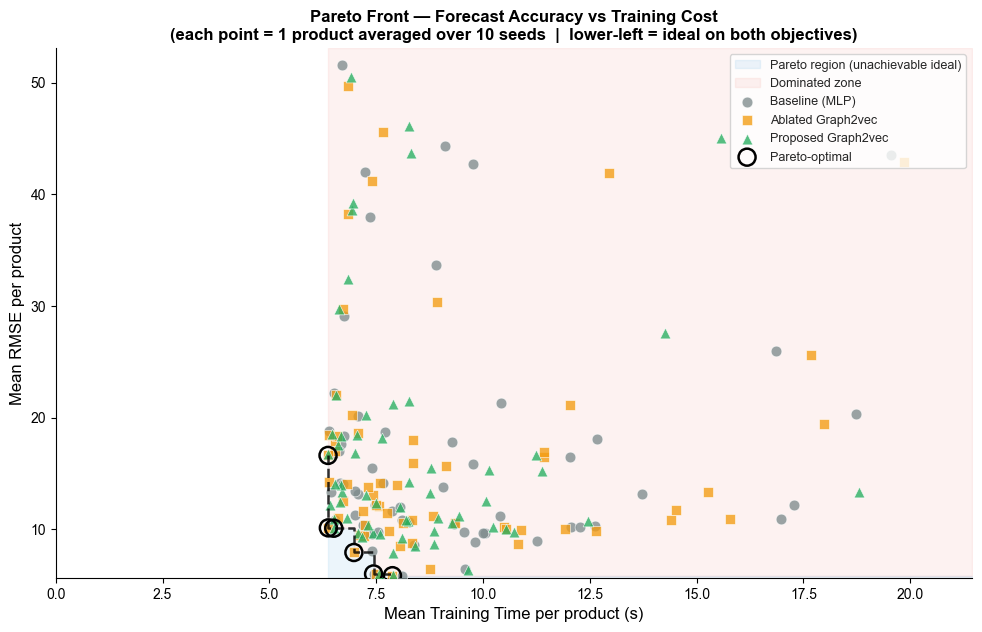

Saved → TimeDistributedMLP/fig_pareto_rmse_traintime.pdf

Pareto-optimal points by condition (total = 6):
condition
Ablated Graph2vec     4
Baseline (MLP)        1
Proposed Graph2vec    1


In [9]:
# ── Aggregate: one point per (product × condition) ───────────────────────────
specs = [
    (BASELINE, 'Baseline (MLP)',     '#7f8c8d', 'o'),
    (ABLATED,  'Ablated Graph2vec',  '#f39c12', 's'),
    (PROPOSED, 'Proposed Graph2vec', '#27ae60', '^'),
]

agg_rows = []
for cond_df, label, color, marker in specs:
    means = cond_df.groupby('item_id')[['rmse', 'train_time']].mean().reset_index()
    means['condition'] = label
    means['color']     = color
    means['marker']    = marker
    agg_rows.append(means)

all_pts = pd.concat(agg_rows, ignore_index=True)

# ── Pareto front (both objectives minimised: RMSE ↓, train_time ↓) ───────────
def pareto_mask(df, obj1, obj2):
    vals = df[[obj1, obj2]].values
    n = len(vals)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j \
               and vals[j, 0] <= vals[i, 0] and vals[j, 1] <= vals[i, 1] \
               and (vals[j, 0] < vals[i, 0] or vals[j, 1] < vals[i, 1]):
                dominated[i] = True
                break
    return ~dominated

all_pts['pareto'] = pareto_mask(all_pts, 'rmse', 'train_time')
front = all_pts[all_pts['pareto']].sort_values('train_time').reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
sns.set_theme(style='whitegrid', font_scale=1.05)

x_max = all_pts['train_time'].max() * 1.08
y_lo  = all_pts['rmse'].min()  * 0.97
y_hi  = all_pts['rmse'].max()  * 1.03

# Extend front to x_max so fill_between reaches the right edge
front_x = np.append(front['train_time'].values, x_max)
front_y = np.append(front['rmse'].values, front['rmse'].values[-1])

# Blue zone  = below the staircase = unachievable ideal (no solution is this good on both)
ax.fill_between(front_x, y_lo, front_y, step='post',
                color='#3498db', alpha=0.09, zorder=1,
                label='Pareto region (unachievable ideal)')

# Red zone   = above the staircase = dominated zone (suboptimal solutions)
ax.fill_between(front_x, front_y, y_hi, step='post',
                color='#e74c3c', alpha=0.07, zorder=1,
                label='Dominated zone')

# Staircase Pareto front
ax.step(front['train_time'], front['rmse'], where='post',
        color='black', linewidth=1.8, linestyle='--', alpha=0.8, zorder=4)

# Scatter all 183 points
for _, label, color, marker in specs:
    pts = all_pts[all_pts['condition'] == label]
    ax.scatter(pts['train_time'], pts['rmse'],
               label=label, color=color, marker=marker,
               s=60, alpha=0.78, edgecolors='white', linewidth=0.5, zorder=3)

# Ring the Pareto-optimal points
ax.scatter(front['train_time'], front['rmse'],
           s=150, facecolors='none', edgecolors='black',
           linewidths=1.8, zorder=5, label='Pareto-optimal')

ax.set_xlim(left=0, right=x_max)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel('Mean Training Time per product (s)', fontsize=12)
ax.set_ylabel('Mean RMSE per product', fontsize=12)
ax.set_title(
    'Pareto Front — Forecast Accuracy vs Training Cost\n'
    '(each point = 1 product averaged over 10 seeds  |  lower-left = ideal on both objectives)',
    fontsize=12, fontweight='bold',
)
ax.legend(frameon=True, fontsize=9, loc='upper right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/fig_pareto_rmse_traintime.pdf', bbox_inches='tight')
plt.show()

print("Saved → TimeDistributedMLP/fig_pareto_rmse_traintime.pdf")
print(f"\nPareto-optimal points by condition (total = {len(front)}):")
print(front.groupby('condition').size().rename('n_pareto_products').to_string())

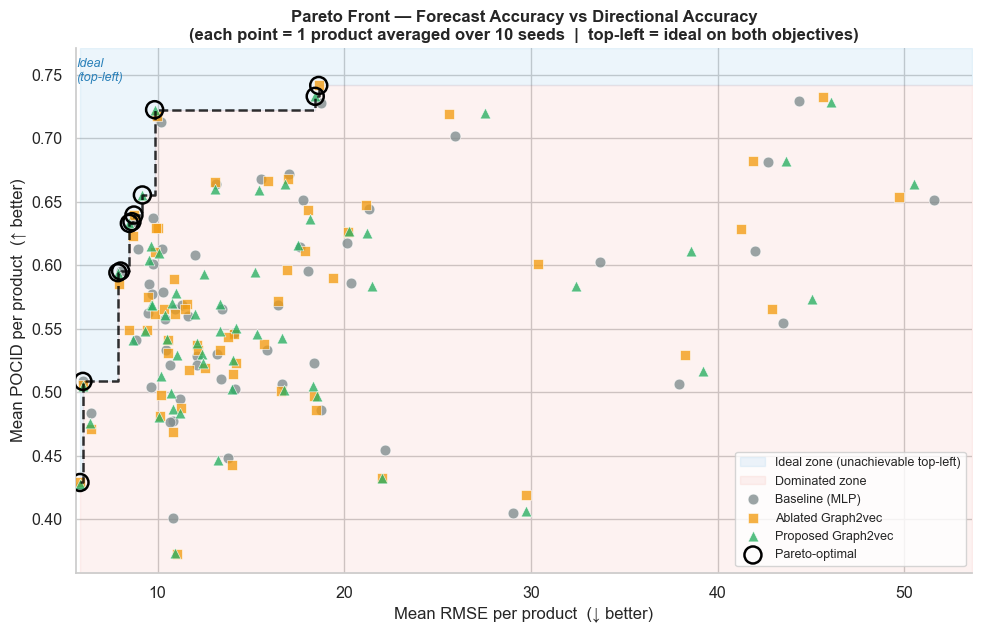

Saved → TimeDistributedMLP/fig_pareto_rmse_pocid.pdf

Pareto-optimal points by condition (total = 11):
condition
Ablated Graph2vec     3
Baseline (MLP)        3
Proposed Graph2vec    5


In [10]:
# ── Aggregate: one point per (product × condition) ───────────────────────────
specs = [
    (BASELINE, 'Baseline (MLP)',     '#7f8c8d', 'o'),
    (ABLATED,  'Ablated Graph2vec',  '#f39c12', 's'),
    (PROPOSED, 'Proposed Graph2vec', '#27ae60', '^'),
]

agg_rows = []
for cond_df, label, color, marker in specs:
    means = cond_df.groupby('item_id')[['rmse', 'pocid']].mean().reset_index()
    means['condition'] = label
    means['color']     = color
    means['marker']    = marker
    agg_rows.append(means)

all_pts = pd.concat(agg_rows, ignore_index=True)

# ── Pareto front: minimise RMSE ↓  AND  maximise POCID ↑ ─────────────────────
# Point i is dominated if ∃ j: rmse_j ≤ rmse_i  AND  pocid_j ≥ pocid_i  (≥1 strict)
def pareto_mask_min_max(df, min_col, max_col):
    vals = df[[min_col, max_col]].values
    n = len(vals)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j \
               and vals[j, 0] <= vals[i, 0] and vals[j, 1] >= vals[i, 1] \
               and (vals[j, 0] < vals[i, 0] or vals[j, 1] > vals[i, 1]):
                dominated[i] = True
                break
    return ~dominated

all_pts['pareto'] = pareto_mask_min_max(all_pts, 'rmse', 'pocid')
# Sort by RMSE ascending — POCID increases along the front (you pay in accuracy to gain direction)
front = all_pts[all_pts['pareto']].sort_values('rmse').reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
sns.set_theme(style='whitegrid', font_scale=1.05)

x_lo  = all_pts['rmse'].min()  * 0.96
x_max = all_pts['rmse'].max()  * 1.04
y_lo  = all_pts['pocid'].min() * 0.96
y_hi  = all_pts['pocid'].max() * 1.04

# Extend staircase to the right edge for fill_between
front_x = np.append(front['rmse'].values,  x_max)
front_y = np.append(front['pocid'].values, front['pocid'].values[-1])

# Blue = above staircase = ideal zone (low RMSE + high POCID) = unachievable top-left
ax.fill_between(front_x, front_y, y_hi, step='post',
                color='#3498db', alpha=0.09, zorder=1,
                label='Ideal zone (unachievable top-left)')

# Red = below staircase = dominated zone (high RMSE + low POCID)
ax.fill_between(front_x, y_lo, front_y, step='post',
                color='#e74c3c', alpha=0.07, zorder=1,
                label='Dominated zone')

# Staircase Pareto boundary
ax.step(front['rmse'], front['pocid'], where='post',
        color='black', linewidth=1.8, linestyle='--', alpha=0.8, zorder=4)

# Scatter all 183 points (61 products × 3 conditions)
for _, label, color, marker in specs:
    pts = all_pts[all_pts['condition'] == label]
    ax.scatter(pts['rmse'], pts['pocid'],
               label=label, color=color, marker=marker,
               s=60, alpha=0.78, edgecolors='white', linewidth=0.5, zorder=3)

# Ring the Pareto-optimal points
ax.scatter(front['rmse'], front['pocid'],
           s=150, facecolors='none', edgecolors='black',
           linewidths=1.8, zorder=5, label='Pareto-optimal')

# Annotate the ideal corner
ax.annotate('Ideal\n(top-left)', xy=(x_lo * 1.01, y_hi * 0.99),
            fontsize=9, color='#2980b9', fontstyle='italic',
            va='top', ha='left')

ax.set_xlim(x_lo, x_max)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel('Mean RMSE per product  (↓ better)', fontsize=12)
ax.set_ylabel('Mean POCID per product  (↑ better)', fontsize=12)
ax.set_title(
    'Pareto Front — Forecast Accuracy vs Directional Accuracy\n'
    '(each point = 1 product averaged over 10 seeds  |  top-left = ideal on both objectives)',
    fontsize=12, fontweight='bold',
)
ax.legend(frameon=True, fontsize=9, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/fig_pareto_rmse_pocid.pdf', bbox_inches='tight')
plt.show()

print("Saved → TimeDistributedMLP/fig_pareto_rmse_pocid.pdf")
print(f"\nPareto-optimal points by condition (total = {len(front)}):")
print(front.groupby('condition').size().rename('n_pareto_products').to_string())

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare

# 1. Carregar os dados
# df = pd.read_csv("seus_resultados.csv")

# 2. Agrupar pelas 10 seeds para ter o valor "médio" de cada modelo por produto
# Assumindo que 'ablate_z' define o seu modelo
df_mean = df.groupby(['item_id', 'ablate_z'])[['rmse', 'mae', 'pocid']].mean().reset_index()

# 3. Calcular os Ranks para cada produto
# Para RMSE e MAE, o menor valor é o melhor (ascending=True)
df_mean['rmse_rank'] = df_mean.groupby('item_id')['rmse'].rank(ascending=True)
df_mean['mae_rank'] = df_mean.groupby('item_id')['mae'].rank(ascending=True)

# Para POCID, o maior valor é o melhor (ascending=False)
df_mean['pocid_rank'] = df_mean.groupby('item_id')['pocid'].rank(ascending=False)

# 4. Calcular o Rank Médio Global (através de todos os 61 produtos)
global_ranks = df_mean.groupby('ablate_z')[['rmse_rank', 'mae_rank', 'pocid_rank']].mean()

print("=== RANK MÉDIO GLOBAL (Menor é melhor) ===")
print(global_ranks)
print("\n")

# 5. Teste Estatístico de Friedman (Exemplo usando RMSE)
# Pivotar a tabela para que cada modelo seja uma coluna e cada linha seja um produto
rmse_pivot = df_mean.pivot(index='item_id', columns='ablate_z', values='rmse')

# Extrair as arrays de cada modelo (certifique-se dos nomes exatos da sua coluna ablate_z)
# Nota: Adapte as strings abaixo se os seus dados tiverem 'baseline', 'True', 'False'
stat, p_value = friedmanchisquare(
    rmse_pivot['baseline'], 
    rmse_pivot['True'], 
    rmse_pivot['False']
)

print("=== TESTE DE FRIEDMAN (RMSE) ===")
print(f"Estatística: {stat:.3f}, p-value: {p_value:.5e}")
if p_value < 0.05:
    print("Conclusão: Existe uma diferença estatisticamente significativa entre os modelos!")
else:
    print("Conclusão: Não há diferença significativa entre os modelos.")

=== RANK MÉDIO GLOBAL (Menor é melhor) ===
          rmse_rank  mae_rank  pocid_rank
ablate_z                                 
False      1.934426  1.934426    2.016393
True       1.934426  1.934426    1.901639
baseline   2.131148  2.131148    2.081967


=== TESTE DE FRIEDMAN (RMSE) ===
Estatística: 1.574, p-value: 4.55261e-01
Conclusão: Não há diferença significativa entre os modelos.
